In [1]:
#this is a simple program to detect pneumoia from chest x-ray , submitted by Haidy Sayed , started this project on June 14th of 2026


import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os


len train N = 1330
len train P = 1330


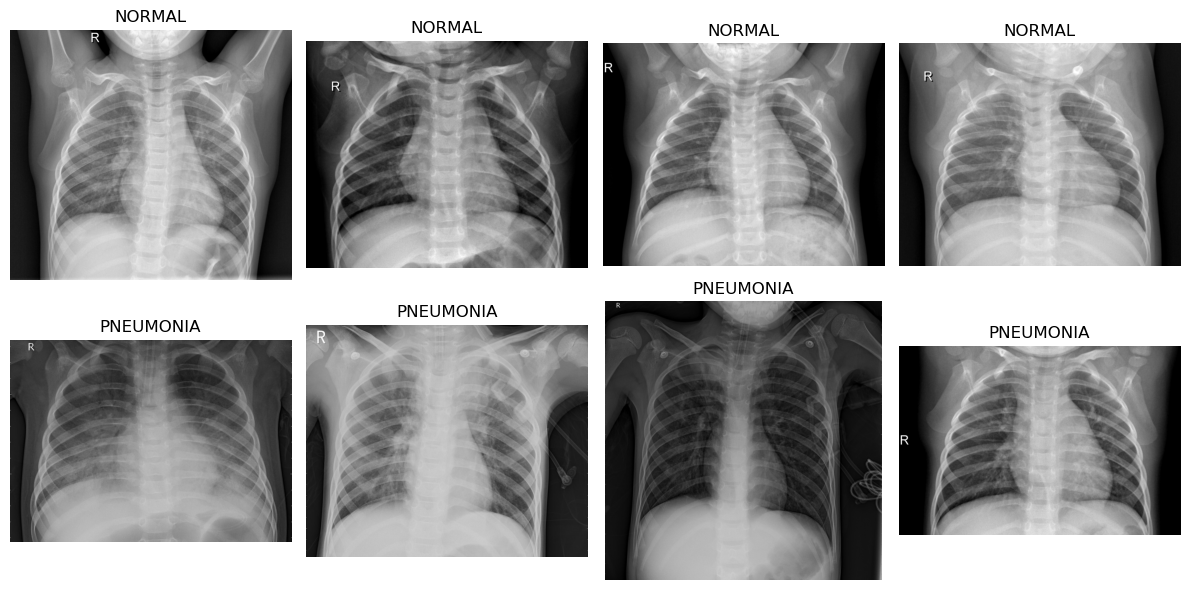

In [2]:
#conting content of each directory

path_train_normal = 'chest_xray\\train\\NORMAL'
path_train_pneumonia = 'chest_xray\\train\\PNEUMONIA'

train_normal = os.listdir(path_train_normal)
train_pneumonia = os.listdir(path_train_pneumonia)

print("len train N = " + str(len(train_normal)))
print("len train P = " + str(len(train_pneumonia)))

# Visualize sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, label in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = f'chest_xray\\train\\{label}'
    images = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.jpeg', '.png'))][:4]
    for j, img_name in enumerate(images):
        img = Image.open(f'{folder}/{img_name}').convert('L')
        axes[i][j].imshow(img, cmap='gray')
        axes[i][j].set_title(label)
        axes[i][j].axis('off')
plt.tight_layout()
plt.savefig('sample_images.png')
plt.show()

In [3]:
#images prep


IMG_SIZE = 128  # choose a fixed size

X = []
Y = []

# NORMAL images
for filename in os.listdir(path_train_normal):
    img_path = os.path.join(path_train_normal, filename)

    img = Image.open(img_path).convert('L')
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img = np.array(img, dtype=np.float32) / 255.0

    X.append(img.flatten())
    Y.append(0)

# PNEUMONIA images
for filename in os.listdir(path_train_pneumonia):
    img_path = os.path.join(path_train_pneumonia, filename)

    img = Image.open(img_path).convert('L')
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img = np.array(img, dtype=np.float32) / 255.0

    X.append(img.flatten())
    Y.append(1)

X = np.array(X)
Y = np.array(Y)

print(X.shape)
# the network needs altered dimensions 
X = X.T
Y = Y.reshape(1, -1)

print(X.shape)
print(Y.shape)

(2660, 16384)
(16384, 2660)
(1, 2660)


In [4]:
class NN_fromScratch:
    def __init__(self, input_size, hidden_size, output_size , learning_rate):
        #using the He initialization (0,sqrt(2/(n-1)))

        self.W1 = np.random.randn(hidden_size , input_size) * np.sqrt(2/input_size)
        self.b1 = np.zeros((hidden_size,1))

        self.W2 = np.random.randn(output_size, hidden_size) * np.sqrt(2/hidden_size)
        self.b2 = np.zeros((output_size,1))

        self.lr = learning_rate


        #Batch norm parameters(learnable gamma and beta)

        self.gamma1 = np.ones((hidden_size, 1))
        self.beta1_bn = np.zeros((hidden_size, 1))

        #running stats 
        self.running_mean = np.zeros((hidden_size,1))
        self.running_var = np.ones((hidden_size,1))
        self.momentum = 0.9

        #Adam optimization parameters , m for momentum , v for velocity , beta1, beta2, and epsilon are initialized to the default recomennded values

        self.beta1, self.beta2, self.epsilon = 0.9, 0.999, 1e-8
        self.m = {k: np.zeros_like(v) for k, v in 
                    {'W1':self.W1,'b1':self.b1,'W2':self.W2,'b2':self.b2,
           'gamma1':self.gamma1,'beta1_bn':self.beta1_bn}.items()}      
        self.v = {k: np.zeros_like(v) for k, v in 
                  {'W1':self.W1,'b1':self.b1,'W2':self.W2,'b2':self.b2,
           'gamma1':self.gamma1,'beta1_bn':self.beta1_bn}.items()}
        self.t = 0
        
        #relu 
    def relu(self, Z):
        return np.maximum(0,Z)


        #sigmoid 

    def sigmoid(self, Z):
        return (1/(1+np.exp(-Z)))

    def forward_prop(self, X , training=True):
        # layer 1
        self.Z1 = np.dot(self.W1,X) + self.b1

        if training : 
            self.mean1 = np.mean(self.Z1, axis=1 , keepdims = True)
            self.var1 = np.var(self.Z1, axis = 1 , keepdims = True)

            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * self.mean1
            self.running_var  = self.momentum * self.running_var  + (1 - self.momentum) * self.var1

        else : # using running stats during testing
            self.mean1 = self.running_mean
            self.var1 = self.running_var

        #forward propagation calculations 

        self.Z1_norm  = (self.Z1 - self.mean1) / np.sqrt(self.var1 + self.epsilon)
        self.Z1_tilde = self.gamma1 * self.Z1_norm + self.beta1_bn  # scale and shift
        self.A1       = self.relu(self.Z1_tilde)


        # Dropout (training only .. dropping 20%)
        if training:
            self.D1 = np.random.rand(*self.A1.shape) > 0.2
            self.A1 = self.A1 * self.D1 / 0.8
        
        # Layer 2
        self.Z2 = np.dot(self.W2, self.A1) + self.b2
        self.A2 = self.sigmoid(self.Z2)

            
        return self.A2



    def compute_loss(self, A2, Y):

        m  = Y.shape[1] #getting the length of the examples
        L2 = (np.sum(self.W1**2) + np.sum(self.W2**2)) * (0.01 /(2*m))
        eps = 1e-8

        return (-np.mean(Y*np.log(A2 + eps) + (1-Y)*np.log(1-A2 +eps)) +L2)

    def back_prop(self, X, Y):

        m = X.shape[1]

        #output gradients

        dZ2 = self.A2 - Y
        dW2 = (1/m)* np.dot(dZ2, self.A1.T) + (0.01/m)*self.W2
        db2 = (1/m) * np.sum(dZ2 , axis = 1, keepdims = True)

        #hidden layer gradients 

        dA1 = np.dot(self.W2.T , dZ2)

        #undo drop out

        dA1 = dA1*self.D1 /0.8

        #relu gradient

        dZ1_tilde = dA1 * (self.Z1_tilde > 0)

        #batch norm gradients gamma and beta_bn

        self.dgamma1 = np.sum(dZ1_tilde * self.Z1_norm , axis = 1, keepdims = True)
        self.dbeta1_bn = np.sum(dZ1_tilde, axis = 1, keepdims = True)

        # Batch norm backward (through normalization)
        dZ1_norm = dZ1_tilde * self.gamma1
            
        dvar1    = np.sum(dZ1_norm * (self.Z1 - self.mean1) * -0.5 *
                              (self.var1 + self.epsilon)**(-1.5), axis=1, keepdims=True)
            
        dmean1   = np.sum(dZ1_norm * -1/np.sqrt(self.var1 + self.epsilon), axis=1, keepdims=True) + \
                       dvar1 * np.mean(-2 * (self.Z1 - self.mean1), axis=1, keepdims=True)
            
        dZ1      = dZ1_norm / np.sqrt(self.var1 + self.epsilon) + \
                       dvar1 * 2 * (self.Z1 - self.mean1) / m + \
                       dmean1 / m

        # Layer 1 weight gradients
        dW1 = (1/m) * np.dot(dZ1, X.T) + (0.01/m) * self.W1      # L2 gradient
        db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    
        self.grads = {'W1':dW1,'b1':db1,'W2':dW2,'b2':db2,
                          'gamma1':self.dgamma1,'beta1_bn':self.dbeta1_bn}

        
    def update(self):
        self.t += 1
        params = {'W1':self.W1,'b1':self.b1,'W2':self.W2,'b2':self.b2,
                      'gamma1':self.gamma1,'beta1_bn':self.beta1_bn}
    
        for key in params:
                # Update moments
            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * self.grads[key]
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * self.grads[key]**2
    
            # Bias correction
            m_corrected = self.m[key] / (1 - self.beta1**self.t)
            v_corrected = self.v[key] / (1 - self.beta2**self.t)
    
            # Update parameter
            params[key] -= self.lr * m_corrected / (np.sqrt(v_corrected) + self.epsilon)
    
        # Write back
        self.W1, self.b1, self.W2, self.b2 = params['W1'], params['b1'], params['W2'], params['b2']
        self.gamma1, self.beta1_bn = params['gamma1'], params['beta1_bn']
    
    def train_step(self, X, Y):
        A2   = self.forward_prop(X, training=True)
        loss = self.compute_loss(A2, Y)
        self.back_prop(X, Y)
        self.update()
        return loss
    
    def predict(self, X):
        A2 = self.forward_prop(X, training=False)
        return (A2 > 0.5).astype(int)
    
                


Epoch 1/50 — Loss: 0.2673
Epoch 2/50 — Loss: 0.1865
Epoch 3/50 — Loss: 0.1654
Epoch 4/50 — Loss: 0.1488
Epoch 5/50 — Loss: 0.1391
Epoch 6/50 — Loss: 0.1359
Epoch 7/50 — Loss: 0.1425
Epoch 8/50 — Loss: 0.1276
Epoch 9/50 — Loss: 0.1223
Epoch 10/50 — Loss: 0.1127
Epoch 11/50 — Loss: 0.0974
Epoch 12/50 — Loss: 0.0984
Epoch 13/50 — Loss: 0.1140
Epoch 14/50 — Loss: 0.1124
Epoch 15/50 — Loss: 0.1029
Epoch 16/50 — Loss: 0.1157
Epoch 17/50 — Loss: 0.1144
Epoch 18/50 — Loss: 0.1055
Epoch 19/50 — Loss: 0.0945
Epoch 20/50 — Loss: 0.0902
Epoch 21/50 — Loss: 0.0928
Epoch 22/50 — Loss: 0.0873
Epoch 23/50 — Loss: 0.1010
Epoch 24/50 — Loss: 0.1021
Epoch 25/50 — Loss: 0.0831
Epoch 26/50 — Loss: 0.0851
Epoch 27/50 — Loss: 0.0787
Epoch 28/50 — Loss: 0.0718
Epoch 29/50 — Loss: 0.0699
Epoch 30/50 — Loss: 0.0677
Epoch 31/50 — Loss: 0.0694
Epoch 32/50 — Loss: 0.0668
Epoch 33/50 — Loss: 0.0869
Epoch 34/50 — Loss: 0.0735
Epoch 35/50 — Loss: 0.0652
Epoch 36/50 — Loss: 0.0874
Epoch 37/50 — Loss: 0.0877
Epoch 38/5

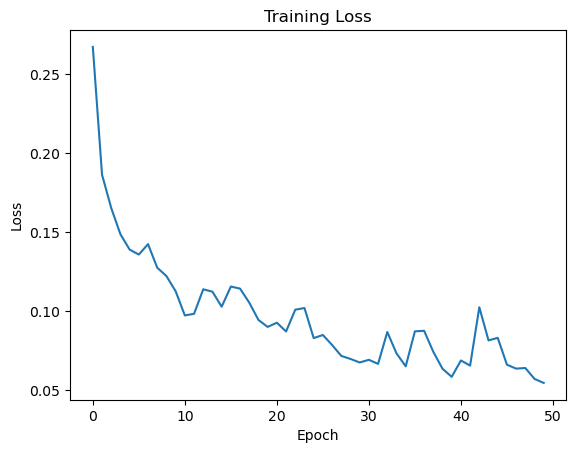

In [5]:
input_size = 128 * 128

hidden_size = 256

output_size = 1

learning_rate = 0.0001

model = NN_fromScratch(input_size, hidden_size, output_size, learning_rate)

num_epochs = 50
batch_size = 32
m = X.shape[1]  # total number of training examples

train_losses = []

for epoch in range(num_epochs):
    
    # shuffle data at start of each epoch
    indices = np.arange(m)
    np.random.shuffle(indices)
    
    # then use those indices to reorder X and Y
    X = X[:, indices]
    Y = Y[:, indices]
    
    epoch_loss = 0
    num_batches = 0
    
    # loop through mini batches
    for i in range(0, m, batch_size):
        X_batch = X[:, i:i+batch_size]
        Y_batch = Y[:, i:i+batch_size]
        
        loss = model.train_step(X_batch, Y_batch)
        epoch_loss += loss
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {avg_loss:.4f}")

# plot loss curve after training
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.savefig('training_loss.png')
plt.show()




(16384, 52)
(1, 52)


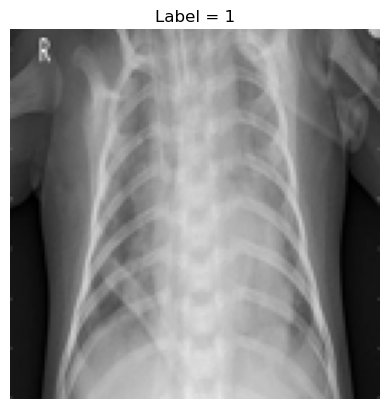

In [6]:

#validate set preprocessing 



IMG_SIZE = 128  # choose a fixed size

X_val= []
Y_val= []
path_val_normal = 'chest_xray\\val\\NORMAL'
path_val_pneumonia = 'chest_xray\\val\\PNEUMONIA'
# NORMAL images
for filename in os.listdir(path_val_normal):
    img_path = os.path.join(path_val_normal, filename)

    img = Image.open(img_path).convert('L')
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img = np.array(img, dtype=np.float32) / 255.0

    X_val.append(img.flatten())
    Y_val.append(0)

# PNEUMONIA images
for filename in os.listdir(path_val_pneumonia):
    img_path = os.path.join(path_val_pneumonia, filename)

    img = Image.open(img_path).convert('L')
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img = np.array(img, dtype=np.float32) / 255.0

    X_val.append(img.flatten())
    Y_val.append(1)

X_val = np.array(X_val)
Y_val = np.array(Y_val)


# the network needs altered dimensions 
X_val = X_val.T
Y_val = Y_val.reshape(1, -1)

print(X_val.shape)
print(Y_val.shape)


##displaying a random image of the val set 

idx = np.random.randint(X_val.shape[1])

img = X_val[:, idx].reshape(128, 128)

plt.imshow(img, cmap='gray')
plt.title(f"Label = {Y_val[0, idx]}")
plt.axis('off')
plt.show()

In [7]:

A2_val = model.forward_prop(X_val, training=False)
val_loss = model.compute_loss(A2_val, Y_val)
print(val_loss)

0.24216367082822773


(624, 16384)
(16384, 624)
(1, 624)


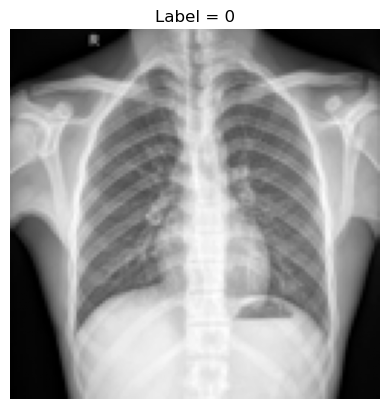

In [8]:

#Test set preprocessing 



IMG_SIZE = 128  # choose a fixed size

X_test= []
Y_test= []
path_test_normal = 'chest_xray\\test\\NORMAL'
path_test_pneumonia = 'chest_xray\\test\\PNEUMONIA'
# NORMAL images
for filename in os.listdir(path_test_normal):
    img_path = os.path.join(path_test_normal, filename)

    img = Image.open(img_path).convert('L')
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img = np.array(img, dtype=np.float32) / 255.0

    X_test.append(img.flatten())
    Y_test.append(0)

# PNEUMONIA images
for filename in os.listdir(path_test_pneumonia):
    img_path = os.path.join(path_test_pneumonia, filename)

    img = Image.open(img_path).convert('L')
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img = np.array(img, dtype=np.float32) / 255.0

    X_test.append(img.flatten())
    Y_test.append(1)

X_test = np.array(X_test)
Y_test = np.array(Y_test)

print(X_test.shape)
# the network needs altered dimensions 
X_test = X_test.T
Y_test = Y_test.reshape(1, -1)

print(X_test.shape)
print(Y_test.shape)

##displaying a random image of the test set 

idx = np.random.randint(X_test.shape[1])

img = X_test[:, idx].reshape(128, 128)

plt.imshow(img, cmap='gray')
plt.title(f"Label = {Y_test[0, idx]}")
plt.axis('off')
plt.show()

In [9]:
predictions = model.predict(X_test)  # returns 0s and 1s

accuracy = np.mean(predictions == Y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 71.79%


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(Y_test.flatten(), predictions.flatten(), 
      target_names=['Normal', 'Pneumonia']))

              precision    recall  f1-score   support

      Normal       1.00      0.25      0.40       234
   Pneumonia       0.69      1.00      0.82       390

    accuracy                           0.72       624
   macro avg       0.84      0.62      0.61       624
weighted avg       0.81      0.72      0.66       624



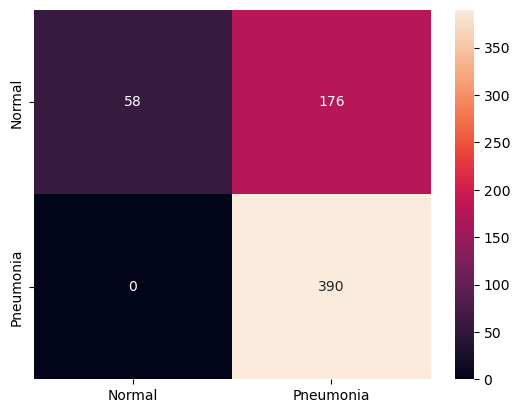

In [11]:
import seaborn as sns

cm = confusion_matrix(Y_test.flatten(), predictions.flatten())
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
plt.savefig('confusion_matrix.png')
plt.show()